#/**************************************
#* NOMBRE: #Cesar Antonio#
#* PRIMER APELLIDO: #Navas#
#* SEGUNDO APELLIDO: #Calatrava#
#* Alias: #Cancalatrava#
#* EMAIL: #cancalatrava@gmail.com#
#***************************************/

In [1]:
# =====================================================================
# CREACION DEL MODELO PREDICTIVO CON EL DATASET DE ENTRENAMIENTO
# =====================================================================

# Carga de librerias
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
import xgboost as xgb
from catboost import CatBoostRegressor
import seaborn as sns
import openpyxl

# Carga del dataset
df = pd.read_excel(r'data/20260427 train_competicion.xlsx')
r2_combo = None

Aplicando KNN Imputer para reconstruir los datos dañados...
Hiper-variables inyectadas con exito!
------------------------------------------------------------
Podado de variables irrelevantes
------------------------------------------------------------
📊 EVALUANDO EL RESULTADO:
    - R2 Obtenido: 0.5918 anterior 0.5918.
    - MAE Obtenido: 0.80
    - RMSE Obtenido: 1.12


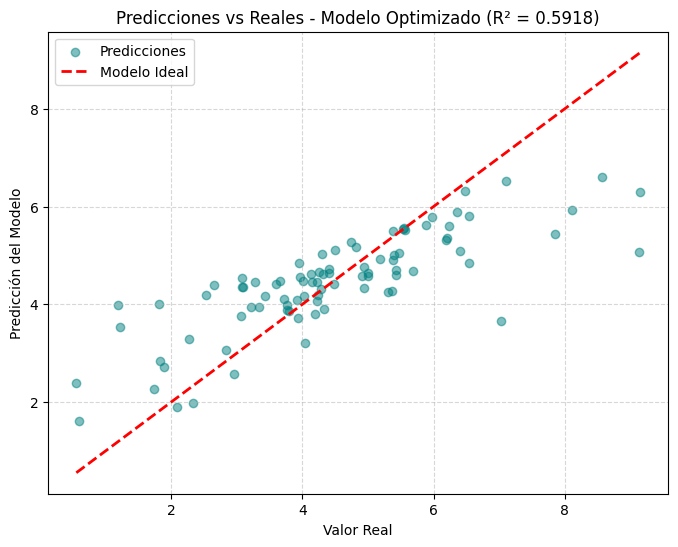

In [ ]:
old_r2_combo = 0
if(r2_combo is not None):
    old_r2_combo = r2_combo
# setup de variables objetivo y de tratamiento
variable_objetivo='deseada'
columnas_deseada = df[variable_objetivo]
columnas_tratar = df.drop(columns=[variable_objetivo])

# Tratamiento de nulos con KNN Imputer
print("Aplicando KNN Imputer para reconstruir los datos dañados...")
knnimputer = KNNImputer(n_neighbors=5)
columnas_num = columnas_tratar.select_dtypes(include=["number"]).columns
columnas_tratar[columnas_num] = knnimputer.fit_transform(df[columnas_num])
df_Knn = columnas_tratar.copy()

# datos limpios por KNN listos para la ingeniería de variables
df_combo = df_Knn.copy()

# COMBO DE VARIABLES por observación de correlaciones y patrones

df_combo["V1_mas_V2"] = df_combo["V1"] + df_combo["V2"]

df_combo["V1_x_V2"] = df_combo["V1"] * df_combo["V2"]
df_combo["V3_x_V5"] = df_combo["V3"] * df_combo["V5"]

df_combo["V5_vs_V6"] = df_combo["V5"] / (df_combo["V6"] + 0.001)
df_combo["V5_vs_V7"] = df_combo["V5"] / (df_combo["V7"] + 0.001)

df_combo["V5_al_cuadrado"] = df_combo["V5"] ** 2
df_combo["V6_al_cuadrado"] = df_combo["V6"] ** 2
df_combo["V4_al_cuadrado"] = df_combo["V4"] ** 2

v9_segura = np.clip(df_combo["V9"], 0.0001, 0.9999)
df_combo["v9_logit"] = np.log(v9_segura / (1 - v9_segura))

print("Hiper-variables inyectadas con exito!")

print("Podado de variables irrelevantes")
variables_aquitar = ["V8", "V2", "V1"]
df_poda = df_combo.drop(columns=variables_aquitar)

# Preparación de matrices X e y
X = df_poda
y = columnas_deseada
X = pd.get_dummies(X, drop_first=True)

# Split de validación (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Setup del Modelo
modelo = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1,
)


modelo.fit(X_train, y_train)

# TEST El Veredicto Final
y_pred = modelo.predict(X_test)
r2_combo = r2_score(y_test, y_pred)
mae_combo = mean_absolute_error(y_test, y_pred)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred))

print("==========================================================")
print("📊 EVALUANDO EL RESULTADO:")
print(f"    - R2 Obtenido: {r2_combo:.4f} anterior {old_r2_combo:.4f}.")
print(f"    - MAE Obtenido: {mae_combo:.2f}")
print(f"    - RMSE Obtenido: {rmse_final:.2f}")
print("==========================================================")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color="teal", label="Predicciones")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Modelo Ideal",
)
plt.title(f"Predicciones vs Reales - Modelo Optimizado (R² = {r2_combo:.4f})")
plt.xlabel("Valor Real")
plt.ylabel("Predicción del Modelo")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

A QUE VARIABLES LE HACE CASO EL MODELO
--------------------------------------------------
1. Variable 'V3_x_V5': 0.2196
2. Variable 'V5_vs_V6': 0.1464
3. Variable 'V0': 0.0884
4. Variable 'V3': 0.0694
5. Variable 'V1_mas_V2': 0.0648
6. Variable 'V5': 0.0565
7. Variable 'V5_vs_V7': 0.0498
8. Variable 'V5_al_cuadrado': 0.0475
9. Variable 'V4_al_cuadrado': 0.0409
10. Variable 'V4': 0.0382
11. Variable 'V6_al_cuadrado': 0.0373
12. Variable 'V6': 0.0371
13. Variable 'V1_x_V2': 0.0335
14. Variable 'V9': 0.0310
15. Variable 'v9_logit': 0.0286
16. Variable 'V7': 0.0109
--------------------------------------------------


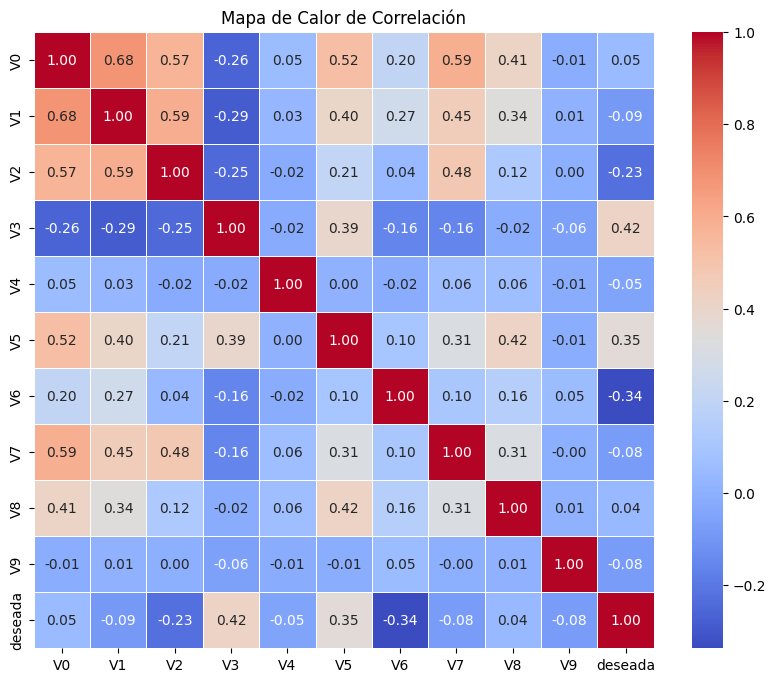

In [4]:
# re-evaluacion del modelo.
importancias = modelo.feature_importances_
indices = np.argsort(importancias)[::-1]

print("A QUE VARIABLES LE HACE CASO EL MODELO")
print("-" * 50)
for f in range(X_train.shape[1]):
    print(
        f"{f + 1}. Variable '{X_train.columns[indices[f]]}': {importancias[indices[f]]:.4f}"
    )
print("-" * 50)

# 2. Mapa de calor de correlación (Para ver si hay variables "clonadas")
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title("Mapa de Calor de Correlación")
plt.show()

In [ ]:
# =====================================================================
# CARGAR LAS NUEVAS BASES DE DATOS Y APLICAR EL MODELO CREADO
# PARA TENER LAS PREDICCIONES
# =====================================================================

# =====================================================================
# 1. CARGAR LA NUEVA BASE DE DATOS
# =====================================================================
df_nuevo_crudo = pd.read_excel(r'data/20260525 test_competicion_entradas.xlsx')

print("Nueva base de datos cargada.")
print(f"🔹 Registros a predecir: {df_nuevo_crudo.shape[0]}")
print("-" * 60)

# =====================================================================
# 2. LIMPIEZA Y TRATAMIENTO DE NULOS
# =====================================================================
print("Limpiando y tratando los datos de la nueva base...")
df_nuevo_limpio = knnimputer.transform(df_nuevo_crudo)

# Lo convertimos de vuelta a DataFrame de Pandas
df_nuevo_procesado = pd.DataFrame(df_nuevo_limpio, columns=df_nuevo_crudo.columns)

# =====================================================================
# 3. REPLICAR ARQUITECTURA (Banderas e Interacciones)
# =====================================================================
print("Inyectando la ingenieria de variables")

# INYECCION DE LAS ORIGINALES

df_nuevo_procesado["V1_mas_V2"] = df_nuevo_procesado["V1"] + df_nuevo_procesado["V2"]

df_nuevo_procesado["V1_x_V2"] = df_nuevo_procesado["V1"] * df_nuevo_procesado["V2"]
df_nuevo_procesado["V3_x_V5"] = df_nuevo_procesado["V3"] * df_nuevo_procesado["V5"]

df_nuevo_procesado["V5_vs_V6"] = df_nuevo_procesado["V5"] / (df_nuevo_procesado["V6"] + 0.001)
df_nuevo_procesado["V5_vs_V7"] = df_nuevo_procesado["V5"] / (df_nuevo_procesado["V7"] + 0.001)

df_nuevo_procesado["V5_al_cuadrado"] = df_nuevo_procesado["V5"] ** 2
df_nuevo_procesado["V6_al_cuadrado"] = df_nuevo_procesado["V6"] ** 2
df_nuevo_procesado["V4_al_cuadrado"] = df_nuevo_procesado["V4"] ** 2

v9_segura = np.clip(df_nuevo_procesado["V9"], 0.0001, 0.9999)
df_nuevo_procesado["v9_logit"] = np.log(v9_segura / (1 - v9_segura))

# Si la nueva base traía una columna llamada 'deseada' la quitamos antes de predecir
if "deseada" in df_nuevo_procesado.columns:
    df_nuevo_procesado = df_nuevo_procesado.drop(columns=["deseada"])

# Aseguramos que el orden de las columnas sea el mismo que vio el modelo
X_nuevo = pd.get_dummies(df_nuevo_procesado, drop_first=True)
X_nuevo = X_nuevo.reindex(columns=X_train.columns, fill_value=0)

# =====================================================================
# 4. PREDICCIÓN Y RELLENO FINAL
# =====================================================================
print("Generando predicciones con el modelo")

predicciones_crudas = modelo.predict(X_nuevo)
predicciones_finales = np.round(predicciones_crudas, 3)
df_nuevo_crudo["deseada_PREDICHO"] = predicciones_finales

print("✅ ¡Base de datos rellenada con éxito!")
print(df_nuevo_crudo[["V1", "V2", "V5", "V6", "deseada_PREDICHO"]].head())

# =====================================================================
# 5. EXPORTAR EL RESULTADO
# =====================================================================

df_nuevo_crudo.to_csv("output/nueva_base_CON_PREDICCIONES.csv", index=False)
df_nuevo_crudo.to_excel("output/nueva_base_CON_PREDICCIONES.xlsx", index=False)
print("\nArchivo 'nueva_base_CON_PREDICCIONES.csv' guardado y listo.")

Nueva base de datos cargada.
🔹 Registros a predecir: 110
------------------------------------------------------------
Limpiando y tratando los datos de la nueva base...
Inyectando la ingenieria de variables
Generando predicciones con el modelo
✅ ¡Base de datos rellenada con éxito!
         V1        V2     V5     V6  deseada_PREDICHO
0  4.887601  1.732051  2.706  1.313             3.923
1  4.010166  1.000000  2.472  0.638             4.402
2  4.873180  2.000000  3.178  1.263             3.915
3  0.000000       NaN  1.334  1.212             4.183
4       NaN  1.000000  1.960  1.020             4.361

Archivo 'nueva_base_CON_PREDICCIONES.csv' guardado y listo.
